<a href="https://colab.research.google.com/github/sultanjacob/Applied-Machine-Learning/blob/main/Phase_10_Dimensionality_Reduction/10_PCA_Predictive_Maintenance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 10: Dimensionality Reduction (PCA)
## Step 1: Data Acquisition and Initial Examination

To demonstrate Principal Component Analysis (PCA), we are using the **SECOM (Semiconductor Manufacturing) Dataset** from the UCI Machine Learning Repository.

This dataset tracks the production of semiconductor wafers. It contains 590 unnamed sensor readings (`Feature_0` to `Feature_589`) and a target variable indicating whether the wafer passed (-1) or failed (1) quality control.

Before we can compress this high-dimensional data, we must first load it into our environment and examine the basic structure and data health (such as missing values) to understand exactly what we are working with.

In [1]:
import pandas as pd
import numpy as np

# 1. Define the direct URLs to the UCI repository
data_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data"
labels_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data"

print("⏳ Loading 590-dimensional sensor data...")

# 2. Load the 590 sensor features (space-separated)
X = pd.read_csv(data_url, sep=" ", header=None)
X.columns = [f"Feature_{i}" for i in range(X.shape[1])]

# 3. Load the target labels (-1 = Pass, 1 = Fail)
y = pd.read_csv(labels_url, sep=" ", header=None, usecols=[0])
y.columns = ['Target']

# 4. Combine into a single DataFrame for Exploration
secom_df = pd.concat([X, y], axis=1)

print("✅ Data Loaded Successfully!\n")

# 5. Examine the structural footprint
print("📊 Structural Overview:")
print(f"Total Rows (Batches): {secom_df.shape[0]}")
print(f"Total Columns (Sensors + Target): {secom_df.shape[1]}")

# 6. Examine Data Health (Missing Values)
total_cells = secom_df.size
total_missing = secom_df.isnull().sum().sum()
missing_percentage = (total_missing / total_cells) * 100

print(f"\n⚠️ Data Health Check:")
print(f"Total Missing Values: {total_missing}")
print(f"Percentage of Missing Data: {missing_percentage:.2f}%")

⏳ Loading 590-dimensional sensor data...
✅ Data Loaded Successfully!

📊 Structural Overview:
Total Rows (Batches): 1567
Total Columns (Sensors + Target): 591

⚠️ Data Health Check:
Total Missing Values: 41951
Percentage of Missing Data: 4.53%


## Step 2: Data Cleaning and Variance Filtering

Principal Component Analysis (PCA) relies entirely on calculating the mathematical variance between features. Because of this, it has two strict requirements: it cannot process missing values (`NaN`), and it gains zero information from sensors that never change (zero variance).

With nearly 42,000 missing values scattered across the dataset, we must execute a precise cleaning strategy before scaling:
1. **Heavy Null Removal:** Drop any sensor missing more than 50% of its readings.
2. **Median Imputation:** Fill the remaining missing values with the median of their respective columns. This preserves the baseline signal without letting extreme outliers warp the replacement value.
3. **Constant Feature Removal:** Drop any sensor that outputs the exact same value for every single batch (0 variance), as it provides no predictive power.

In [2]:
print("⚙️ Cleaning missing values and constant features...\n")

# 1. Identify and drop columns missing more than 50% of their data
missing_fractions = secom_df.isnull().mean()
cols_to_drop_nulls = missing_fractions[missing_fractions > 0.5].index
secom_cleaned = secom_df.drop(columns=cols_to_drop_nulls).copy()

# 2. Impute remaining missing values with the median of each column
secom_cleaned.fillna(secom_cleaned.median(), inplace=True)

# 3. Identify and drop constant features (sensors with 0 variance)
features_only = secom_cleaned.drop(columns=['Target'])
constant_cols = features_only.columns[features_only.nunique() <= 1]
secom_cleaned.drop(columns=constant_cols, inplace=True)

# 4. Display the results
print(f"🗑️ Sensors dropped due to >50% missing data: {len(cols_to_drop_nulls)}")
print(f"🗑️ Sensors dropped due to 0 variance (constant): {len(constant_cols)}")
print(f"📊 New Dataset Shape: {secom_cleaned.shape[0]} rows, {secom_cleaned.shape[1]} columns")

# 5. Verify the data is mathematically sound for PCA
remaining_nulls = secom_cleaned.isnull().sum().sum()
print(f"✅ Remaining Missing Values: {remaining_nulls}")

⚙️ Cleaning missing values and constant features...

🗑️ Sensors dropped due to >50% missing data: 28
🗑️ Sensors dropped due to 0 variance (constant): 116
📊 New Dataset Shape: 1567 rows, 447 columns
✅ Remaining Missing Values: 0


## Step 3: Visualizing the Sensor Audit

Before applying complex mathematical transformations, it is critical to document the integrity of the raw data.

Out of the original 590 sensors on the manufacturing line, our automated cleaning script identified that over 20% of the data streams were unusable. Specifically, 116 sensors were completely static (broken or providing a constant zero-variance signal), and 28 sensors were failing to report data more than half the time. Visualizing this audit provides clear justification to stakeholders for why these specific data points were permanently removed from the pipeline.

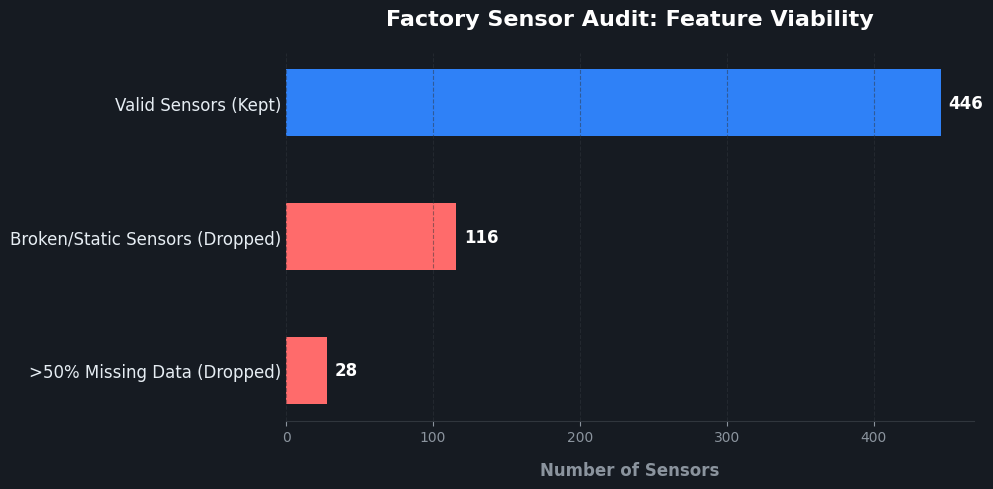

In [3]:
import matplotlib.pyplot as plt

# 1. Define the exact counts from our cleaning step (446 valid features + 1 target = 447 columns)
categories = ['Valid Sensors (Kept)', 'Broken/Static Sensors (Dropped)', '>50% Missing Data (Dropped)']
counts = [446, 116, 28]

# 2. Premium dark corporate theme
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 5), facecolor='#161b22')
ax.set_facecolor('#161b22')

# 3. Plot horizontal bars (Blue for kept, Red for dropped)
bars = ax.barh(categories, counts, color=['#2f81f7', '#ff6b6b', '#ff6b6b'], height=0.5)

# 4. Add bold data labels directly to the bars
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())}',
            va='center', ha='left', color='white', fontweight='bold', fontsize=12)

# 5. Professional typography and formatting
ax.set_title('Factory Sensor Audit: Feature Viability',
             color='white', fontsize=16, fontweight='bold', pad=20, loc='center')
ax.set_xlabel('Number of Sensors', color='#8b949e', fontsize=12, fontweight='bold', labelpad=12)

# 6. Strip away visual clutter
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#30363d')
ax.tick_params(axis='y', colors='#e6edf3', labelsize=12, length=0)
ax.tick_params(axis='x', colors='#8b949e', labelsize=10)
ax.grid(axis='x', color='#30363d', linestyle='--', alpha=0.5)

# 7. Ensure largest bar is at the top
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## Step 4: Feature Scaling (The PCA Prerequisite)

Principal Component Analysis is fundamentally a variance-maximizing algorithm. Because of this, it is highly sensitive to the scale of our data.

If Sensor A measures machine temperature in decimals (e.g., 0.5 °C) and Sensor B measures rotor speed in thousands (e.g., 5,000 RPM), PCA will assume Sensor B is vastly more important simply because its raw numbers are larger.

To prevent this artificial bias, we must standardize our dataset before applying PCA. We will use `StandardScaler` to force every single sensor to have a mean of 0 and a standard deviation of 1. This puts all 446 remaining sensors on the exact same mathematical playing field.

In [4]:
from sklearn.preprocessing import StandardScaler

print("⚖️ Standardizing sensor scales...")

# 1. Separate the features from the target label
X_cleaned = secom_cleaned.drop(columns=['Target'])
y_labels = secom_cleaned['Target']

# 2. Initialize and apply the StandardScaler
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_cleaned)

# 3. Convert back to a Pandas DataFrame for readability
X_scaled = pd.DataFrame(X_scaled_array, columns=X_cleaned.columns)

# 4. Verify the scaling worked (Mean should be ~0, Std Dev should be ~1)
print("\n✅ Scaling Complete. Verification of first 3 sensors:")
for col in X_scaled.columns[:3]:
    col_mean = X_scaled[col].mean()
    col_std = X_scaled[col].std()
    print(f"{col}: Mean = {col_mean:.2f}, Std Dev = {col_std:.2f}")

print(f"\n📊 Matrix ready for PCA: {X_scaled.shape[0]} rows, {X_scaled.shape[1]} features.")

⚖️ Standardizing sensor scales...

✅ Scaling Complete. Verification of first 3 sensors:
Feature_0: Mean = 0.00, Std Dev = 1.00
Feature_1: Mean = -0.00, Std Dev = 1.00
Feature_2: Mean = -0.00, Std Dev = 1.00

📊 Matrix ready for PCA: 1567 rows, 446 features.


## Step 5: Fitting PCA and Calculating Explained Variance

Now that our 446 remaining sensors are mathematically balanced, we can feed them into the PCA algorithm.

Before we decide how much to compress the dataset, we need to understand how the mathematical signal (variance) is distributed. We will fit PCA to the full dataset and calculate the **Cumulative Explained Variance**. This allows us to map exactly how many Principal Components are required to retain our target threshold (typically 95%) of the original machine's diagnostic information, allowing us to drop the rest as redundancy and noise.

In [5]:
from sklearn.decomposition import PCA
import numpy as np

print("🧠 Fitting PCA to the scaled sensor data...\n")

# 1. Initialize and fit PCA on all 446 features to capture the full variance profile
pca_full = PCA()
pca_full.fit(X_scaled)

# 2. Calculate the cumulative variance explained by each successive component
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# 3. Find the exact number of components needed for key business thresholds
components_90 = np.argmax(cumulative_variance >= 0.90) + 1
components_95 = np.argmax(cumulative_variance >= 0.95) + 1
components_99 = np.argmax(cumulative_variance >= 0.99) + 1

# 4. Display the compression results
print("📉 Compression Thresholds:")
print(f"Components for 90% Variance: {components_90} (Dropped {446 - components_90} sensors)")
print(f"Components for 95% Variance: {components_95} (Dropped {446 - components_95} sensors)")
print(f"Components for 99% Variance: {components_99} (Dropped {446 - components_99} sensors)")

🧠 Fitting PCA to the scaled sensor data...

📉 Compression Thresholds:
Components for 90% Variance: 129 (Dropped 317 sensors)
Components for 95% Variance: 162 (Dropped 284 sensors)
Components for 99% Variance: 216 (Dropped 230 sensors)


## Step 6: Visualizing the Variance (The Scree Plot)

The mathematical output reveals a massive redundancy on the factory floor. By retaining just **162 components**, we can capture **95%** of the entire machine's diagnostic variance. This allows us to permanently delete 284 sensors from our model, massively reducing computational load and entirely eliminating multicollinearity.

To make this mathematical decision interpretable for stakeholders, we use a Cumulative Variance Plot (often called a Scree Plot). This visualizes the "elbow" curve, proving exactly where we hit diminishing returns—where adding more sensors adds only noise, not value.

📊 Generating Cumulative Variance Plot...


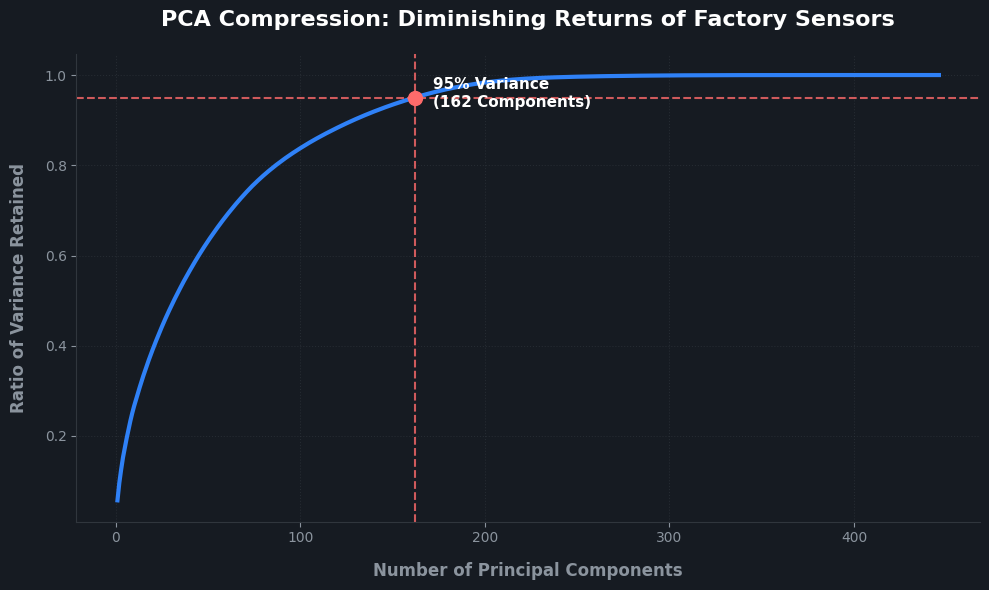

In [6]:
import matplotlib.pyplot as plt

print("📊 Generating Cumulative Variance Plot...")

# 1. Setup the dark corporate theme
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6), facecolor='#161b22')
ax.set_facecolor('#161b22')

# 2. Plot the cumulative variance curve
ax.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
        color='#2f81f7', linewidth=3, label='Cumulative Variance')

# 3. Add a marker and lines for the 95% business threshold (162 components)
ax.axhline(y=0.95, color='#ff6b6b', linestyle='--', linewidth=1.5, alpha=0.8)
ax.axvline(x=components_95, color='#ff6b6b', linestyle='--', linewidth=1.5, alpha=0.8)
ax.scatter(components_95, 0.95, color='#ff6b6b', s=100, zorder=5)

# 4. Add text annotation for the sweet spot
ax.text(components_95 + 10, 0.93, f'95% Variance\n(162 Components)',
        color='white', fontweight='bold', fontsize=11)

# 5. Professional typography and formatting
ax.set_title('PCA Compression: Diminishing Returns of Factory Sensors',
             color='white', fontsize=16, fontweight='bold', pad=20, loc='center')
ax.set_xlabel('Number of Principal Components', color='#8b949e', fontsize=12, fontweight='bold', labelpad=12)
ax.set_ylabel('Ratio of Variance Retained', color='#8b949e', fontsize=12, fontweight='bold', labelpad=12)

# 6. Clean up visual clutter
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#30363d')
ax.spines['bottom'].set_color('#30363d')
ax.tick_params(axis='both', colors='#8b949e', labelsize=10)
ax.grid(color='#30363d', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()